In [1]:
import pandas as pd
import os

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

## Main Code

In [3]:
from src.components.module_04_feature_quality_check import orchastrator,load_clean_df
from sklearn.model_selection import train_test_split
import logging
from src.logger import config_logger
import os 
from src.exception import MyException
import numpy as np
import pandas as pd
from optbinning import OptimalBinning
import gc

logger = config_logger('module_05_feature_engineering.py')


id_col = "SK_ID_CURR"
target_col = "TARGET"

def handle_missing_values(df, id_col="SK_ID_CURR"):
    num_cols = (
        df.select_dtypes(include=[np.number])
        .select_dtypes(exclude=["bool"])
        .columns
        .drop(id_col)
    )

    df[num_cols] = df[num_cols].fillna(-99999)
    return df


#-----------------------------------------------------------------
class NumericalWOEBinner:
    """
    Numerical WOE Binning using optbinning
    - Fit on TRAIN only
    - Transform TRAIN / TEST safely
    """
    def __init__(self, id_col, special_codes=None, max_n_bins=20, min_prebin_size=0.05):
        self.id_col = id_col
        self.special_codes = special_codes
        self.max_n_bins = max_n_bins
        self.min_prebin_size = min_prebin_size
        
        self.binning_models = {}
        self.iv_df = None
        self.numerical_features = []

    def fit(self, X_train_num, y_train):
        """
        X_train_num: pd.DataFrame containing only numerical features including id_col
        """
        self.numerical_features = [c for c in X_train_num.columns if c != self.id_col]
        iv_records = []

        for col in self.numerical_features:
            try:
                optb = OptimalBinning(
                    name=col,
                    dtype="numerical",
                    solver="cp",
                    prebinning_method="quantile",
                    min_prebin_size=self.min_prebin_size,
                    max_n_bins=self.max_n_bins,
                    special_codes=self.special_codes
                )

                # Fit on TRAIN only
                optb.fit(X_train_num[col], y_train)

                # Build binning table
                bt = optb.binning_table
                bt.build()

                # Store model
                self.binning_models[col] = optb

                # Store IV
                iv_records.append({
                    "feature": col,
                    "iv": bt.iv
                })

            except MyException as e:
                print(f"Skipped {col}: {e}")

        self.iv_df = pd.DataFrame(iv_records).sort_values(by="iv", ascending=False).reset_index(drop=True)
        return self

    def transform(self, X_num):
        X_woe = pd.DataFrame(index=X_num.index)
        X_woe[self.id_col] = X_num[self.id_col]

        for col, optb in self.binning_models.items():
            if col not in X_num.columns:
                continue
            X_woe[col + "_WOE"] = optb.transform(X_num[col].fillna(-99999), metric="woe")

        return X_woe

    def fit_transform(self, X_train_num, y_train):
        self.fit(X_train_num, y_train)
        return self.transform(X_train_num)

#-----------------------------------------------------------------
class CategoricalWOEBinner:
    """
    Categorical WOE Binning
    - One bin per category
    - Rare grouping
    - Train-only WOE calculation
    - Safe transform for TEST
    """
    def __init__(self, id_col, rare_threshold=0.01, eps=1e-6):
        self.id_col = id_col
        self.rare_threshold = rare_threshold
        self.eps = eps

        self.categorical_features = []
        self.cat_woe_maps = {}
        self.iv_df = None
        
    def get_categorical_woe_bins(self,cat_woe_maps):
        records = []

        for feature, info in cat_woe_maps.items():
            woe_map = info["woe_map"]
            rare_cats = info["rare_categories"]

            for bin_name, woe in woe_map.items():
                records.append({
                    "feature": feature,
                    "bin": bin_name,
                    "woe": woe,
                    "is_rare_bin": bin_name == "RARE",
                    "rare_categories": ", ".join(rare_cats) if bin_name == "RARE" else None
                })

        return pd.DataFrame(records)
    
    def fit(self, X_train_cat, y_train):
        """
        X_train_cat: pd.DataFrame containing only categorical features including id_col
        """
        self.categorical_features = [c for c in X_train_cat.columns if c != self.id_col]
        cat_iv_records = []
        
        for col in self.categorical_features:
            train_series = X_train_cat[col].fillna("MISSING")

            # Frequency on TRAIN
            freq = train_series.value_counts(normalize=True)
            
            if freq.min() <= self.rare_threshold:
                logger.info(f"Min frequency of category: {freq.min()}")

            # Rare categories
            rare_categories = freq[freq < self.rare_threshold].index.tolist()

            # Apply rare grouping
            train_binned = train_series.where(~train_series.isin(rare_categories), "RARE")

            df_tmp = pd.DataFrame({"cat": train_binned, "target": y_train})

            # Aggregate
            agg = df_tmp.groupby("cat").agg(total=("target", "count"), bad=("target", "sum")).reset_index()
            agg["good"] = agg["total"] - agg["bad"]

            total_good = agg["good"].sum()
            total_bad = agg["bad"].sum()

            # Distributions
            agg["dist_good"] = agg["good"] / total_good
            agg["dist_bad"] = agg["bad"] / total_bad

            # WOE
            agg["woe"] = np.log((agg["dist_good"] + self.eps) / (agg["dist_bad"] + self.eps))

            # IV
            agg["iv"] = (agg["dist_good"] - agg["dist_bad"]) * agg["woe"]
            iv_value = agg["iv"].sum()

            # Store WOE map for this feature
            woe_map = dict(zip(agg["cat"], agg["woe"]))
            self.cat_woe_maps[col] = {"woe_map": woe_map, "rare_categories": rare_categories}

            # Store IV
            cat_iv_records.append({"feature": col, "iv": iv_value})

        self.iv_df = pd.DataFrame(cat_iv_records).sort_values(by="iv", ascending=False).reset_index(drop=True)
        return self

    def transform(self, X_cat):
        X_woe = pd.DataFrame(index=X_cat.index)
        X_woe[self.id_col] = X_cat[self.id_col]

        for col in self.categorical_features:
            if col not in self.cat_woe_maps:
                continue

            woe_map = self.cat_woe_maps[col]["woe_map"]
            rare_categories = self.cat_woe_maps[col]["rare_categories"]

            if "RARE" not in woe_map:
                woe_map["RARE"] = 0.0

            test_series = X_cat[col].fillna("MISSING")
            test_binned = test_series.where(~test_series.isin(rare_categories), "RARE")
            test_binned = test_binned.where(test_binned.isin(woe_map.keys()), "RARE")
            X_woe[col + "_WOE"] = test_binned.map(woe_map)

        return X_woe

    def fit_transform(self, X_train_cat, y_train):
        self.fit(X_train_cat, y_train)
        return self.transform(X_train_cat)
#-----------------------------------------------------------------

class FeatureEngineeringPipeline:
    def __init__(self, id_col, target_col):
        self.id_col = id_col
        self.target_col = target_col
        

        self.num_binner = NumericalWOEBinner(
            id_col=id_col,
            special_codes={
                "SC_-99999": [-99999],
                "SC_-88888": [-88888],
                "SC_-77777": [-77777],
            }
        )

        self.cat_binner = CategoricalWOEBinner(
            id_col=id_col,
            rare_threshold=0.01
        )

    def fit(self, df):
        
        logger.info("Starting Feature Engineering Pipeline")


        X = df.drop(columns=[self.target_col])
        y = df[self.target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        
        # Missing handling
        X_train = handle_missing_values(X_train, self.id_col)
        X_test  = handle_missing_values(X_test, self.id_col)

        
        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = X_train.select_dtypes(include=["object", "category","bool"]).columns.tolist()
        
        # always keep id column
        num_cols = list(dict.fromkeys([self.id_col] + num_cols))
        cat_cols = list(dict.fromkeys([self.id_col] + cat_cols))

        # split datasets
        X_train_num = X_train[num_cols]
        X_train_cat = X_train[cat_cols]
        
        X_test_num  = X_test[num_cols]
        X_test_cat  = X_test[cat_cols]
        logger.info(f"Data split completed. Shape of splits Before Woe Calculation: X_train: {X_train.shape},X_Test {X_test.shape}")

        # delete the Df  and the X to free up memory 
        del  X, df
        gc.collect()

       
        logger.info("Missing numerical values filled with special code (-99999)")

        
        logger.info("Fitting Numerical WOE binner on TRAIN data")
        X_train_num_woe = self.num_binner.fit_transform(X_train_num, y_train).astype(np.float32)


        logger.info("Fitting Categorical WOE binner on TRAIN data")        
        X_train_cat_woe = self.cat_binner.fit_transform(X_train_cat, y_train).astype(np.float32)
        
        skipped_numerical = [col for col in X_train_num.columns if col != self.id_col and col not in self.num_binner.binning_models]
        logger.info(f"Numerical features skipped in WOE binning: {skipped_numerical}")

        skipped_categorical = [col for col in X_train_cat.columns if col != self.id_col and col not in self.cat_binner.cat_woe_maps]
        logger.info(f"Categorical features skipped in WOE binning: {skipped_categorical}")


        logger.info("Transforming TEST data using trained WOE binning")
        X_test_num_woe = self.num_binner.transform(X_test_num)
        X_test_cat_woe = self.cat_binner.transform(X_test_cat)
        

            
        # MERGE FEATURES woe into single dataframe
        X_train_final_woe   = X_train_num_woe.merge(X_train_cat_woe,on=id_col,how='left')     
        
        del X_train_num_woe, X_train_cat_woe
        logger.info(f'Free Up memory by Reducing TRAIN: X_train_num_woe, X_train_cat_woe')
        gc.collect()

        X_test_final_woe = X_test_num_woe.merge(X_test_cat_woe,on=id_col,how='left')     
    
        del X_test_num_woe, X_test_cat_woe
        logger.info(f'Free Up memory by Reducing  TEST: X_test_num_woe, X_test_cat_woe')
        gc.collect()

        logger.info(
            f"WOE features merged | Final Feature Train shape: {X_train_final_woe.shape}"
        )
        
        
        # Free up the iv Binner Memory
        iv_num = self.num_binner.iv_df.copy()
        iv_cat = self.cat_binner.iv_df.copy()
        
        iv_df = (
            pd.concat([iv_num, iv_cat], axis=0)
            .reset_index(drop=True)
            )
        
        # free binner memory
        self.num_binner.iv_df = None
        self.cat_binner.iv_df = None
        
        # categorical bins dataset
        cat_woe_maps = runner.cat_binner.cat_woe_maps
        cat_bin_df  = runner.cat_binner.get_categorical_woe_bins(cat_woe_maps)
        

        logger.info("Feature Engineering Pipeline executed successfully")

        return {
            # model-ready
            'cat_bin_df':cat_bin_df,
            'X_train_df':X_train,
            "X_train_final_woe": X_train_final_woe,
            "X_test_final_woe": X_test_final_woe,
            "y_train": y_train,
            "y_test": y_test,

            # diagnostics 
            'iv_df':iv_df,
            "iv_num_train": iv_num,
            "iv_cat_train": iv_cat,

        }
data_path = r"D:\home loan credit risk\artifact\interim\main_df_transformed.csv"

df = pd.read_csv(data_path)

# downcast floats (memory-safe)
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = pd.to_numeric(df[col], downcast="float")

print("Main DF shape:", df.shape)
feature_quality_csv_path = orchastrator(df)
feature_quality_df = pd.read_csv(feature_quality_csv_path)


df = load_clean_df(df, feature_quality_df)


print("DF shape after quality filter:", df.shape)
runner = FeatureEngineeringPipeline(id_col=id_col, target_col=target_col)

artifacts = runner.fit(df)

X_train = artifacts["X_train_final_woe"]
X_test  = artifacts["X_test_final_woe"]
y_train = artifacts["y_train"]
y_test  = artifacts["y_test"]

iv_df   = artifacts["iv_df"]
iv_num  = artifacts["iv_num_train"]
iv_cat  = artifacts["iv_cat_train"]
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

assert X_train.isna().sum().sum() == 0, "NaNs in X_train"
assert X_test.isna().sum().sum() == 0, "NaNs in X_test"

iv_df.head()

Main DF shape: (307511, 316)


2026-02-03 12:47:48,012 - module_05_feature_engineering.py - INFO - Starting Feature Engineering Pipeline


DF shape after quality filter: (307511, 289)


2026-02-03 12:47:59,073 - module_05_feature_engineering.py - INFO - Data split completed. Shape of splits Before Woe Calculation: X_train: (215257, 288),X_Test (92254, 288)
2026-02-03 12:48:00,962 - module_05_feature_engineering.py - INFO - Missing numerical values filled with special code (-99999)
2026-02-03 12:48:00,964 - module_05_feature_engineering.py - INFO - Fitting Numerical WOE binner on TRAIN data
c:\ProgramData\anaconda3\envs\homecredit\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\ProgramData\anaconda3\envs\homecredit\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\ProgramData\anaconda3\envs\homecredit\Lib\site-packages\sklearn\preprocessing\_discretizat

Train shape: (215257, 288)
Test shape : (92254, 288)


,feature,iv
0,EXT_SOURCE_3,0.341411
1,EXT_SOURCE_2,0.313613
2,EXT_SOURCE_1,0.154088
3,YEARS_EMPLOYED,0.103587
4,IP_WORST_DPD_720D,0.091186


In [4]:
#Basic Filterartion
iv_df["feature"] = iv_df["feature"] + "_WOE"

iv_threshold= 0.02
# keep features above threshold
filt = iv_df["iv"] >= iv_threshold

keep_features= iv_df.loc[filt,"feature"].tolist()

removed_low_iv_ = iv_df.loc[
iv_df["iv"] < iv_threshold, ["feature", "iv"]
]

X_filtered_woe = X_train[keep_features]
print(f'X_train.shape {X_train.shape}')
print(f' remained feature{removed_low_iv_}')

X_train.shape (215257, 288)
 remained feature                            feature        iv
178           BASEMENTAREA_MODE_WOE  0.019941
179              FLOORSMIN_MEDI_WOE  0.019071
180               FLOORSMIN_AVG_WOE  0.018932
181  AMT_REQ_CREDIT_BUREAU_YEAR_WOE  0.018024
182       CB_WT_CREDIT_USAGE_1M_WOE  0.017478
..                              ...       ...
282          FONDKAPREMONT_MODE_WOE  0.011759
283                FLAG_OWN_CAR_WOE  0.007289
284             NAME_TYPE_SUITE_WOE  0.000920
285  WEEKDAY_APPR_PROCESS_START_WOE  0.000783
286             FLAG_OWN_REALTY_WOE  0.000635

[100 rows x 2 columns]


### Numerical analysis


In [5]:
########################
#NUMERICAL DATAFRAME BINS

import pandas as pd
feature_bins = {}

# Loop through all numerical features in the WOE binner
for feature, optb in runner.num_binner.binning_models.items():
    
    # Make sure the binning table is built
    bt = optb.binning_table
    bt_df = bt.build()
    bt_df["feature"] = feature
    
    feature_bins[feature] = bt_df
#############################################

# create a df with num special values ,  and missing values

feature_list = list(feature_bins.keys())
rows = []

for feature in feature_list:
    temp = feature_bins[feature]
    filt1 = temp['Bin'] =='MISSING'
    
    #special values ratio
    filt2 = (temp['Bin'] =='SC_-99999') | (temp['Bin'] =='SC_-88888') | (temp['Bin'] =='SC_-77777')
    special_values_ratio = temp.loc[filt2]['Count (%)'].sum()

    #missing values ratio
    missing_ratio = temp.loc[filt1]['Count (%)'].sum()
    
    rows.append({
        "feature": feature,
        "missing_rate": missing_ratio,
        "special_rate": special_values_ratio
    })
new_df = pd.DataFrame(rows)
new_df['feature'] = new_df['feature']+'_WOE'


# feature quality dataframe from  bsaic filteration features columns 
iv_series = (
    iv_df
    .set_index("feature")["iv"]
    .loc[X_filtered_woe.columns]
)
iv_series = iv_series.to_frame().reset_index()
iv_series = iv_series.rename(columns={'index':'feature'})

num_feature_quality = new_df.merge(iv_series,on='feature',how='left')
num_feature_quality = num_feature_quality[num_feature_quality['iv'].notnull()]
# score for the feature selection hearusitic approch
num_feature_quality['score'] =  (0.7 * num_feature_quality['iv']) - (
                (0.2 * num_feature_quality['missing_rate']) + (0.1 * num_feature_quality['special_rate'])
            )#set index as feature
num_feature_quality = num_feature_quality.set_index('feature')

In [7]:
import pickle
num_bin_path = os.path.join('artifact', "numerical_feature_bins.pkl")

with open(num_bin_path, "wb") as f:
    pickle.dump(feature_bins, f)

In [8]:
with open(num_bin_path, "rb") as f:
    feature_bins = pickle.load(f)


In [10]:
feature_bins

{'CNT_CHILDREN':                  Bin   Count  Count (%)  Non-event  Event  Event rate  \
 0       (-inf, 1.00)  150712   0.700149     139091  11621    0.077107   
 1       [1.00, 2.00)   42855   0.199088      39021   3834    0.089464   
 2        [2.00, inf)   21690   0.100763      19733   1957    0.090226   
 3          SC_-99999       0   0.000000          0      0    0.000000   
 4          SC_-88888       0   0.000000          0      0    0.000000   
 5          SC_-77777       0   0.000000          0      0    0.000000   
 6            Missing       0   0.000000          0      0    0.000000   
 Totals                215257   1.000000     197845  17412    0.080889   
 
              WoE        IV        JS       feature  
 0        0.05199  0.001852  0.000231  CNT_CHILDREN  
 1      -0.110133  0.002529  0.000316  CNT_CHILDREN  
 2      -0.119445  0.001511  0.000189  CNT_CHILDREN  
 3            0.0  0.000000  0.000000  CNT_CHILDREN  
 4            0.0  0.000000  0.000000  CNT_CHI

### categorical selection

In [6]:
import pandas as pd

rows = []

# Use the raw X_train (before WOE transformation)
X_train_raw = artifacts['X_train_df']
# Or if you saved the original X_train somewhere before WOE, use that

for feature in runner.cat_binner.categorical_features:  # raw names
    total_count = len(X_train_raw)

    # Missing rate: check original raw column
    if feature in X_train_raw.columns:
        missing_rate = X_train_raw[feature].isna().sum() / total_count
        rare_categories = runner.cat_binner.cat_woe_maps[feature]["rare_categories"]
        rare_rate = X_train_raw[feature].isin(rare_categories).sum() / total_count
    else:
        # If the raw column is not available, fallback to 0
        missing_rate = 0
        rare_rate = 0

    # IV from binner
    iv_value = iv_cat.loc[
        iv_cat["feature"] == feature, "iv"
    ].values[0]

    rows.append({
        "feature": feature + "_WOE",
        "missing_rate": missing_rate,
        "rare_rate": rare_rate,
        "iv": iv_value
    })

cat_feature_quality = pd.DataFrame(rows)

# Feature quality score
cat_feature_quality["score"] = (
    (0.7 * cat_feature_quality["iv"])
    - (0.2 * cat_feature_quality["missing_rate"])
    - (0.1 * cat_feature_quality["rare_rate"])
)
cat_feature_quality = cat_feature_quality.set_index('feature')

In [7]:
cat_feature_quality

,missing_rate,rare_rate,iv,score
feature,,,,
NAME_CONTRACT_TYPE_WOE,0.000000,0.000000,0.015776,0.011043
CODE_GENDER_WOE,0.000000,0.000014,0.038812,0.027167
FLAG_OWN_CAR_WOE,0.000000,0.000000,0.007289,0.005102
FLAG_OWN_REALTY_WOE,0.000000,0.000000,0.000635,0.000444
NAME_TYPE_SUITE_WOE,0.004241,0.009551,0.000920,-0.001159
NAME_INCOME_TYPE_WOE,0.000000,0.000186,0.056246,0.039353
NAME_EDUCATION_TYPE_WOE,0.000000,0.000544,0.049006,0.034250
NAME_FAMILY_STATUS_WOE,0.000000,0.000005,0.023031,0.016121
NAME_HOUSING_TYPE_WOE,0.000000,0.012250,0.014736,0.009090


In [8]:
# Ensure both DataFrames have same columns
num_feature_quality['rare_rate'] = 0.0   # no rare categories in numeric features
cat_feature_quality['special_rate'] = 0.0  # no special values in categorical features

# Reset index to have 'feature' as a column if needed
#num_feature_quality = num_feature_quality.reset_index()
#cat_feature_quality = cat_feature_quality.reset_index()

# Concatenate
feature_quality_final = pd.concat([num_feature_quality, cat_feature_quality], axis=0)

# Sort by score
feature_quality_final = feature_quality_final.sort_values("score", ascending=False)


In [9]:
feature_quality_final

,missing_rate,special_rate,iv,score,rare_rate
feature,,,,,
EXT_SOURCE_2_WOE,0.000000,0.002197,0.313437,0.219186,0.000000
EXT_SOURCE_3_WOE,0.000000,0.199004,0.341411,0.219088,0.000000
YEARS_EMPLOYED_WOE,0.000000,0.000000,0.102729,0.071910,0.000000
YEARS_AGE_WOE,0.000000,0.000000,0.086334,0.060434,0.000000
AMT_GOODS_PRICE_WOE,0.000000,0.000924,0.074131,0.051799,0.000000
...,...,...,...,...,...
CB_AVG_ATM_WITHDRAWAL_FREQ_1M_WOE,0.000000,0.865909,0.021310,-0.071674,0.000000
EMERGENCYSTATE_MODE_WOE,0.474117,0.000000,0.022947,-0.079517,0.007558
WALLSMATERIAL_MODE_WOE,0.508601,0.000000,0.025836,-0.085486,0.018508


#### group wise feature selection corr+iv

In [10]:

import numpy as np
import pandas as pd

# ==============================
# PARAMETERS
# ==============================
corr_threshold = 0.7

# Ensure alignment
X_woe = X_filtered_woe.astype(np.float32)
feature_quality_final = feature_quality_final.copy()

# Keep only common features
common_features = X_woe.columns.intersection(feature_quality_final.index)
X_woe = X_woe[common_features]
feature_quality_final = feature_quality_final.loc[common_features]

# ==============================
# CORRELATION MATRIX
# ==============================
corr_matrix = X_woe.corr().abs()

# Upper triangle (avoid duplicates & self-corr)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

drop_features = set()
visited = set()

# ==============================
# CORR + SCORE FILTER LOGIC
# ==============================
for feature in upper.columns:

    if feature in visited or feature in drop_features:
        continue

    # Find all features correlated with `feature`
    correlated = upper.index[upper[feature] > corr_threshold].tolist()

    if not correlated:
        visited.add(feature)
        continue

    # Form correlation group (feature + its correlated ones)
    group = set(correlated + [feature])

    # Remove already dropped features
    group = [f for f in group if f not in drop_features]

    if len(group) <= 1:
        visited.update(group)
        continue

    # Select best feature based on SCORE
    best_feature = (
        feature_quality_final
        .loc[group]
        .sort_values("score", ascending=False)
        .index[0]
    )

    # Drop all others
    for f in group:
        if f != best_feature:
            drop_features.add(f)

    visited.update(group)

# ==============================
# FINAL SELECTED FEATURES
# ==============================
selected_features = [f for f in X_woe.columns if f not in drop_features]

print(f"Total features before : {X_woe.shape[1]}")
print(f"Total features after  : {len(selected_features)}")
print(f"Dropped features      : {len(drop_features)}")

Total features before : 187
Total features after  : 46
Dropped features      : 141


In [14]:
iv_df[iv_df['feature'].isin(selected_features)]

,feature,iv
0,EXT_SOURCE_3_WOE,0.341411
1,EXT_SOURCE_2_WOE,0.313437
2,EXT_SOURCE_1_WOE,0.154088
3,YEARS_EMPLOYED_WOE,0.102729
6,CB_MAX_MONTHLY_UTIL_12M_WOE,0.089690
14,YEARS_AGE_WOE,0.086334
20,B_RATIO_DEBT_TO_LOAN_WOE,0.077853
26,AMT_GOODS_PRICE_WOE,0.074131
28,IP_RATIO_EARLY_PAYMENTS_2160D_WOE,0.070180
31,B_NUM_ACTIVE_CREDIT_360D_WOE,0.068224


In [13]:

# CODE_GENDER: conatin missing as rare categories handle it as missing 
# NAME_TYPE_SUITE contain rare categories that are Other_B, MISSING, Other_A, Group of people no missing values
# NAME_INCOME_TYPE: Unemployed, Student, Businessman, Maternity leave
# NAME_EDUCATION_TYPE:  Academic degree
# NAME_FAMILY_STATUS : Missing Rare category
# NAME_HOUSING_TYPE Office apartment, Co-op apartment
# OCCUPATION_TYPE:  Private service staff, Low-skill Laborers, Waiters/barmen staff, Secretaries, Realty agents, HR staff, IT staff
# WEEKDAY_APPR_PROCESS_START: doesnt have rare and missing

# ORGANIZATION_TYPE :  RARE :'Housing, Industry: type 11, Military, Bank, Agriculture, Police, Transport: type 2, Postal, Security Ministries, Trade: type 2, Restaurant, Services, University, Industry: type 7, Transport: type 3, Industry: type 1, Hotel, Electricity, Industry: type 4, Trade: type 6, Insurance, Industry: type 5, Telecom, Emergency, Industry: type 2, Advertising, Culture, Realtor, Industry: type 12, Trade: type 1, Mobile, Legal Services, Cleaning, Transport: type 1, Industry: type 6, Industry: type 10, Religion, Industry: type 13, Trade: type 4, Trade: type 5, Industry: type 8'
# Missing category: missing bin
# FONDKAPREMONT_MODE : MISSING bin
# HOUSETYPE_MODE: MISSING , rare specific housing, terraced house
# WALLSMATERIAL_MODE : MISSING, rare: Mixed, Monolithic, Others
# EMERGENCYSTATE_MODE MISSING, Rare :Yes


In [ ]:
cat_bin_df = artifacts['cat_bin_df']

In [1]:
cat_bin_df

NameError: name 'cat_bin_df' is not defined

In [27]:
cat_bin_df['feature'].unique()

array(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START',
       'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'], dtype=object)

## categorical feature analysis after the iv_+corr

In [100]:
# Analyis of this grup
can = corr_matrix.loc['ENTRANCES_MEDI_WOE'].to_frame()
filt = can['ENTRANCES_MEDI_WOE'] > 0.7
new_list = can.loc[filt].index.tolist()
new_list

['TOTALAREA_MODE_WOE',
 'LIVINGAREA_AVG_WOE',
 'LIVINGAREA_MEDI_WOE',
 'LIVINGAREA_MODE_WOE',
 'APARTMENTS_AVG_WOE',
 'APARTMENTS_MEDI_WOE',
 'APARTMENTS_MODE_WOE',
 'ENTRANCES_MEDI_WOE',
 'ENTRANCES_AVG_WOE',
 'ENTRANCES_MODE_WOE',
 'BASEMENTAREA_MEDI_WOE',
 'BASEMENTAREA_AVG_WOE',
 'WALLSMATERIAL_MODE_WOE',
 'EMERGENCYSTATE_MODE_WOE',
 'HOUSETYPE_MODE_WOE']

In [101]:
te = []
for i in new_list:
    for j in selected_features:
        if i==j:
            te.append(i)
te

['ENTRANCES_MEDI_WOE']

In [102]:
feature_quality_final.loc[new_list].sort_values(by='score',ascending=False)

,missing_rate,special_rate,iv,score,rare_rate
TOTALAREA_MODE_WOE,0.000000,0.482702,0.035918,-0.023127,0.000000
LIVINGAREA_AVG_WOE,0.000000,0.502116,0.033621,-0.026677,0.000000
LIVINGAREA_MEDI_WOE,0.000000,0.502116,0.033433,-0.026809,0.000000
LIVINGAREA_MODE_WOE,0.000000,0.502116,0.032562,-0.027418,0.000000
APARTMENTS_AVG_WOE,0.000000,0.507765,0.032362,-0.028123,0.000000
APARTMENTS_MEDI_WOE,0.000000,0.507765,0.032266,-0.028190,0.000000
APARTMENTS_MODE_WOE,0.000000,0.507765,0.031498,-0.028728,0.000000
ENTRANCES_MEDI_WOE,0.000000,0.503668,0.026541,-0.031788,0.000000
ENTRANCES_AVG_WOE,0.000000,0.503668,0.026235,-0.032002,0.000000
ENTRANCES_MODE_WOE,0.000000,0.503668,0.025800,-0.032307,0.000000


In [1]:
#ENTRANCES_MEDI_WOE

<Axes: >

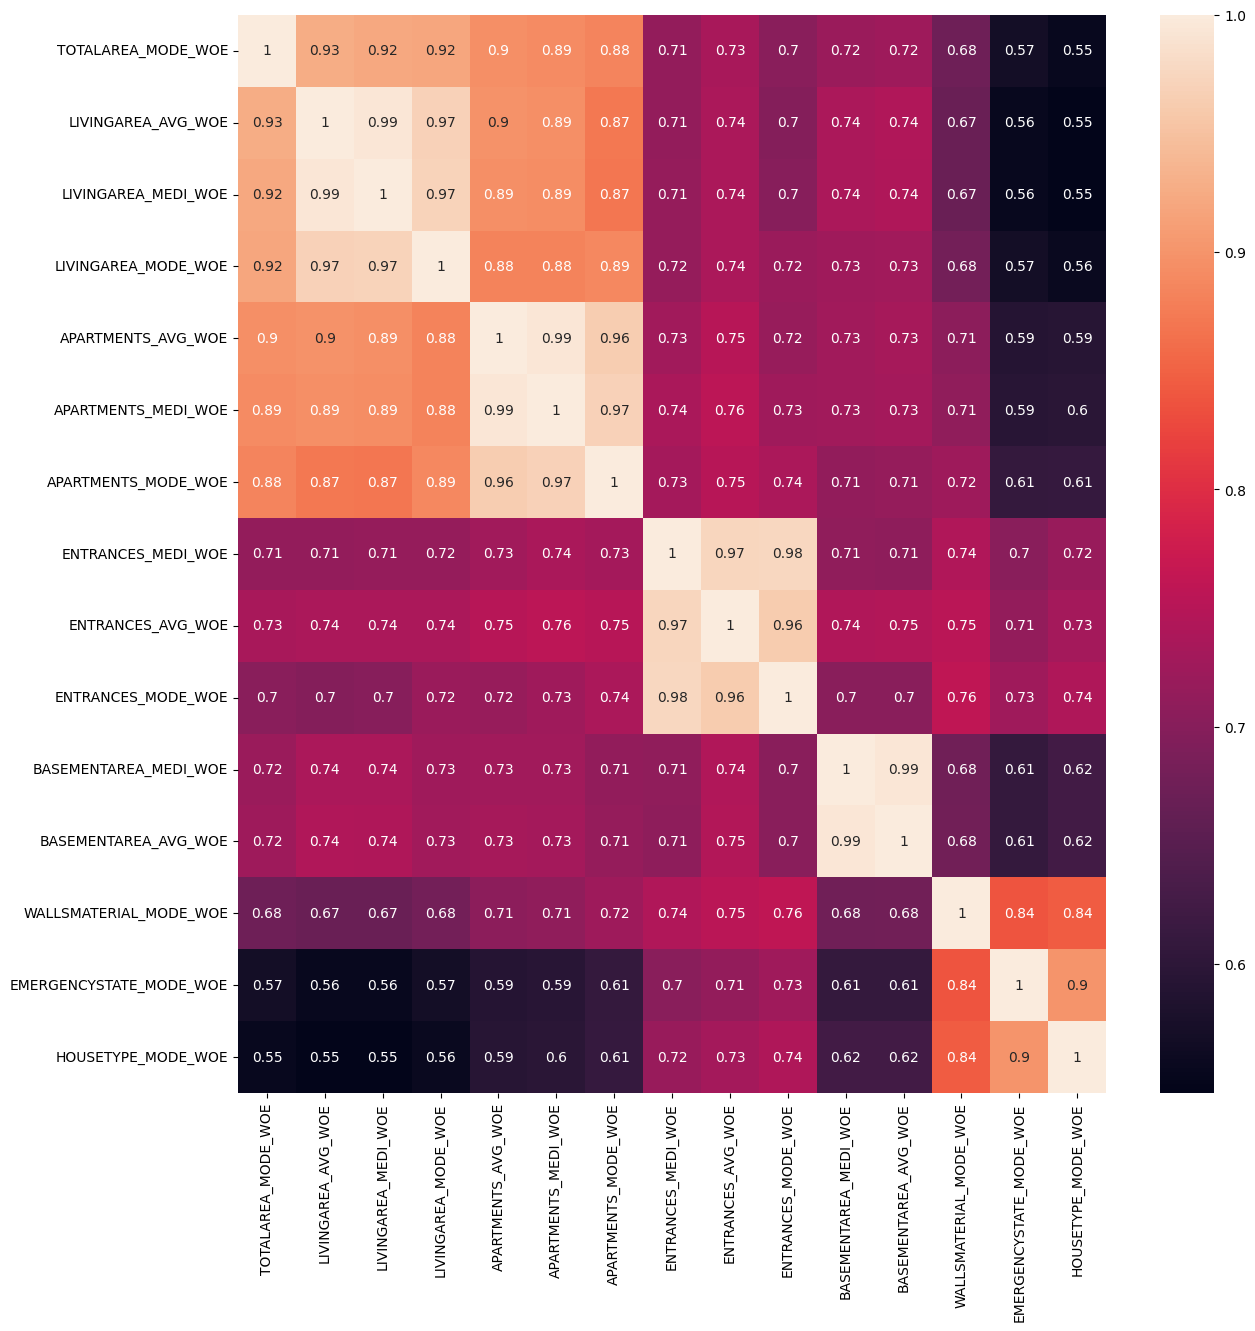

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,14))
sns.heatmap(X_filtered_woe[new_list].corr().abs(),annot=True)